# Case-Based Reasoning — Putusan Sengketa Pajak
**Mata Kuliah:** Penalaran Komputer — Semester Genap 2025/2026  
**Program Studi:** Teknik Informatika, Universitas Muhammadiyah Malang  
**NIM:** 202310370311358  
**SubCPMK-3:** Implementasi siklus Case-Based Reasoning menggunakan dataset putusan Mahkamah Agung RI

---
### Siklus CBR yang diimplementasikan:
1. **Tahap 1** — Membangun Case Base (konversi PDF + preprocessing)
2. **Tahap 2** — Case Representation (ekstraksi metadata & fitur)
3. **Tahap 3** — Case Retrieval (TF-IDF + SVM + fungsi `retrieve()`)
4. **Tahap 4** — Solution Reuse (prediksi amar putusan)
5. **Tahap 5** — Model Evaluation (Accuracy, Precision, Recall, F1)

---
## ⚙️ Setup: Install Dependencies & Mount Google Drive

In [5]:
# Install semua library yang dibutuhkan
!pip install -q pdfminer.six nltk scikit-learn pandas matplotlib seaborn tqdm openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 18.0 MB/s eta 0:00:00


In [6]:
import os, re, time, json, pickle, logging, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity
from pdfminer.high_level import extract_text as pdf_extract
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
print('✅ Semua library berhasil diimport.')

✅ Semua library berhasil diimport.


In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive berhasil di-mount.')

Mounted at /content/drive
✅ Google Drive berhasil di-mount.


In [8]:
# ================================================================
# KONFIGURASI PATH — Sesuaikan nama folder jika berbeda
# ================================================================
DRIVE_BASE    = Path('/content/drive/MyDrive/TUBES PENKOM')

PDF_DIR       = DRIVE_BASE / 'data/raw/pdfs'
RAW_DIR       = DRIVE_BASE / 'data/raw'
PROCESSED_DIR = DRIVE_BASE / 'data/processed'
EVAL_DIR      = DRIVE_BASE / 'data/eval'
RESULTS_DIR   = DRIVE_BASE / 'data/results'
LOG_DIR       = DRIVE_BASE / 'logs'

# Buat semua folder jika belum ada
for d in [PDF_DIR, RAW_DIR, PROCESSED_DIR, EVAL_DIR, RESULTS_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Cek PDF tersedia
pdf_files = sorted(PDF_DIR.glob('*.pdf'))
print(f'📁 Base folder : {DRIVE_BASE}')
print(f'📄 PDF tersedia: {len(pdf_files)} file')
if len(pdf_files) < 30:
    print(f'⚠️  PERHATIAN: Butuh minimal 30 PDF. Baru ada {len(pdf_files)}.')
else:
    print('✅ Jumlah PDF mencukupi (≥30).')

📁 Base folder : /content/drive/MyDrive/TUBES PENKOM
📄 PDF tersedia: 30 file
✅ Jumlah PDF mencukupi (≥30).


---
## 📁 Tahap 1: Membangun Case Base
**Tujuan:** Konversi PDF putusan → teks bersih, siap diproses model.

> PDF sudah diunduh manual dari [putusan.pajak.go.id](https://www.pajak.go.id/id/putusan-pengadilan-pajak) (Sengketa Pajak → Pajak Penghasilan / PPN / PBB)

### 1.1 Konversi PDF → Teks

In [9]:
def pdf_to_text(pdf_path):
    """Konversi satu file PDF ke string teks menggunakan pdfminer."""
    try:
        text = pdf_extract(str(pdf_path))
        return text if text and len(text.strip()) > 100 else None
    except Exception as e:
        return None

# Test konversi satu file
if pdf_files:
    sample = pdf_to_text(pdf_files[0])
    print(f'Contoh teks (100 karakter pertama):')
    print(sample[:200] if sample else 'GAGAL — coba file lain')
else:
    print('⚠️ Tidak ada PDF di folder. Pastikan sudah upload ke Google Drive.')

Contoh teks (100 karakter pertama):
Direktori Putusan Mahkamah Agung Republik Indonesia
putusan.mahkamahagung.go.id

Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Re


### 1.2 Fungsi Pembersihan Teks

In [10]:
def clean_text(text):
    """
    Bersihkan teks putusan Pengadilan Pajak:
    - Hapus header/footer, nomor halaman, watermark Pengadilan Pajak
    - Normalisasi spasi dan karakter
    """
    if not text:
        return ''

    # Hapus nomor halaman
    text = re.sub(r'-\s*\d+\s*-', '', text)
    text = re.sub(r'Hal\.?\s*\d+\s*(dari|of)\s*\d+', '', text, flags=re.IGNORECASE)

    # Hapus header/footer standar MA
    for pattern in [
        r'Disclaimer[^\n]*\n?',
        r'Kepaniteraan[^\n]*\n?',
        r'Mahkamah Agung Republik Indonesia[^\n]*\n?',
        r'putusan\.mahkamahagung\.go\.id',
        r'www\.mahkamahagung\.go\.id',
        r'DIREKTORI PUTUSAN[^\n]*\n?',
        r'\f',
    ]:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # Normalisasi whitespace
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

# Test
if pdf_files:
    raw = pdf_to_text(pdf_files[0])
    cleaned = clean_text(raw)
    print(f'Panjang teks asli  : {len(raw) if raw else 0} karakter')
    print(f'Panjang teks bersih: {len(cleaned)} karakter')
    print(f'Contoh:\n{cleaned[:300]}')

Panjang teks asli  : 16094 karakter
Panjang teks bersih: 10838 karakter
Contoh:
pelaksanaan fungsi peradilan. Namun dalam hal-hal tertentu masih dimungkinkan terjadi permasalahan teknis terkait dengan akurasi dan keterkinian informasi yang kami sajikan, hal mana akan terus kami perbaiki dari waktu kewaktu.
Dalam hal Anda menemukan inakurasi informasi yang termuat pada situs ini


### 1.3 Fungsi Validasi Teks

In [11]:
def validate_text(text, min_words=200):
    """
    Validasi teks: dianggap valid jika
    - Minimal min_words kata
    - Mengandung kata kunci putusan sengketa pajak
    """
    if not text:
        return False, 0
    wc = len(text.split())
    keywords = ['putusan', 'pemohon', 'sengketa', 'mengadili', 'pasal', 'pajak']
    has_kw = any(kw in text.lower() for kw in keywords)
    return wc >= min_words and has_kw, wc

print('✅ Fungsi validasi siap.')

✅ Fungsi validasi siap.


### 1.4 Pipeline Utama: Konversi Semua PDF

In [12]:
# Setup logging
logging.basicConfig(
    filename=str(LOG_DIR / 'cleaning.log'),
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

saved, skipped = 0, 0
metadata_log = []

for i, pdf_path in enumerate(tqdm(pdf_files, desc='Konversi PDF')):
    # Konversi PDF → teks
    raw = pdf_to_text(pdf_path)
    if not raw:
        logging.warning(f'GAGAL konversi: {pdf_path.name}')
        skipped += 1
        continue

    # Bersihkan
    cleaned = clean_text(raw)

    # Validasi
    is_valid, wc = validate_text(cleaned)
    if not is_valid:
        logging.warning(f'SKIP (tidak valid): {pdf_path.name} | words={wc}')
        skipped += 1
        continue

    # Simpan sebagai .txt
    case_id = f'case_{saved+1:03d}'
    out_path = RAW_DIR / f'{case_id}.txt'
    out_path.write_text(cleaned, encoding='utf-8')

    metadata_log.append({
        'case_id'    : case_id,
        'file_asal'  : pdf_path.name,
        'word_count' : wc
    })
    logging.info(f'SAVED: {case_id} | words={wc} | {pdf_path.name}')
    saved += 1

print(f'\n=== Hasil Tahap 1 ===')
print(f'✅ Tersimpan : {saved} dokumen')
print(f'⚠️  Dilewati  : {skipped} dokumen')
print(f'📁 Lokasi    : {RAW_DIR}')

Konversi PDF: 100%|██████████| 30/30 [01:30<00:00,  3.03s/it]


=== Hasil Tahap 1 ===
✅ Tersimpan : 30 dokumen
⚠️  Dilewati  : 0 dokumen
📁 Lokasi    : /content/drive/MyDrive/TUBES PENKOM/data/raw


### 1.5 Verifikasi Akhir Tahap 1

In [13]:
txt_files = sorted(RAW_DIR.glob('*.txt'))
print(f'Total file .txt di data/raw/: {len(txt_files)}')

assert len(txt_files) >= 30, f'❌ KURANG! Hanya {len(txt_files)}/30 dokumen'
print('✅ Jumlah dokumen mencukupi (≥30)')

df_log = pd.DataFrame(metadata_log)
if not df_log.empty:
    print(f"\nStatistik kata per dokumen:")
    print(f"  Rata-rata : {df_log['word_count'].mean():.0f} kata")
    print(f"  Minimum   : {df_log['word_count'].min()} kata")
    print(f"  Maximum   : {df_log['word_count'].max()} kata")
    df_log.to_csv(LOG_DIR / 'download_log.csv', index=False)
    display(df_log.head(5))

print('\n✅ Tahap 1 SELESAI')

Total file .txt di data/raw/: 30
✅ Jumlah dokumen mencukupi (≥30)

Statistik kata per dokumen:
  Rata-rata : 1703 kata
  Minimum   : 1399 kata
  Maximum   : 2212 kata


,case_id,file_asal,word_count
0,case_001,putusan_1022_b_pk_pjk_2026_20260609174507.pdf,1448
1,case_002,putusan_1030_b_pk_pjk_2026_20260608104217.pdf,1843
2,case_003,putusan_1059_b_pk_pjk_2026_20260609174432.pdf,1898
3,case_004,putusan_1445_b_pk_pjk_2026_20260609175410.pdf,1435
4,case_005,putusan_4401_b_pk_pjk_2025_20260609174336.pdf,1404



✅ Tahap 1 SELESAI


---
## 📊 Tahap 2: Case Representation
**Tujuan:** Ekstraksi metadata dan fitur teks dari setiap putusan → format terstruktur `.csv`

### 2.1 Fungsi Ekstraksi Metadata

In [14]:
def classify_verdict(amar_text):
    t = amar_text.lower()

    # Dikabulkan / ditolak
    if any(w in t for w in ['dikabulkan seluruhnya', 'mengabulkan seluruh']):
        return 'dikabulkan_penuh'

    # Cek jenis pajak spesifik
    if 'pajak penghasilan' in t: return 'sengketa_pph'
    if 'pajak pertambahan nilai' in t or 'ppn' in t: return 'sengketa_ppn'
    if 'pajak bumi dan bangunan' in t or 'pbb' in t: return 'sengketa_pbb'
    if 'bea masuk' in t: return 'sengketa_bea_masuk'
    if 'pajak daerah' in t: return 'sengketa_pajak_daerah'

    # Kalau amar tidak terdeteksi
    if any(w in t for w in ['ditolak', 'menolak permohonan']):
        return 'ditolak'

    return 'unknown'

In [15]:
def extract_amar(text):
    """Ekstrak amar putusan dari teks putusan MA."""
    pattern = r'(?:M\s*E\s*N\s*G\s*A\s*D\s*I\s*L\s*I|MENGADILI)(.{50,2000})(?:Demikianlah|Ditetapkan|Hakim Ketua|Hakim Anggota)'
    m = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
    if m:
        amar = re.sub(r'\s+', ' ', m.group(1).strip())
        return amar[:800]
    return 'UNKNOWN'

def extract_no_perkara(text):
    """Ekstrak nomor perkara dari teks."""
    m = re.search(r'(?:Nomor|Putusan Nomor)\s*(\d+\/[\w\-\.]+\/\d{4})', text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    return 'UNKNOWN'

def extract_tanggal(text):
    """Ekstrak tanggal putusan dari teks."""
    m = re.search(r'(?:tanggal|pada tanggal)\s*(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})', text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    return 'UNKNOWN'

def extract_pasal(text):
    """Ekstrak pasal yang relevan dari teks."""
    m = re.search(r'(Pasal\s+\d+(\s+ayat\s+\d+)?\s+(?:UU|Undang-Undang|Peraturan)?\s*(?:PPh|PPN|PBB|KUP)?(?:\s+\w+)*)', text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    return 'UNKNOWN'

def extract_pihak(text):
    """Ekstrak pihak-pihak terkait dari teks (pemohon dan termohon)."""
    pemohon = re.search(r'(Pemohon(?: Peninjauan Kembali)?\s*:\s*([^,\n]+))', text, re.IGNORECASE)
    termohon = re.search(r'(Termohon(?: Peninjauan Kembali)?\s*:\s*([^,\n]+))', text, re.IGNORECASE)
    pihak = []
    if pemohon:
        pihak.append(f"Pemohon: {pemohon.group(2).strip()}")
    if termohon:
        pihak.append(f"Termohon: {termohon.group(2).strip()}")
    return ' | '.join(pihak) if pihak else 'UNKNOWN'

def classify_verdict(amar_text):
    """Klasifikasi amar putusan ke label kelas."""
    t = amar_text.lower()
    if any(w in t for w in ['dikabulkan seluruhnya', 'mengabulkan seluruh']):
        return 'dikabulkan_penuh'
    if 'pajak penghasilan' in t: return 'sengketa_pph'
    if 'pajak pertambahan nilai' in t or 'ppn' in t: return 'sengketa_ppn'
    if 'pajak bumi dan bangunan' in t or 'pbb' in t: return 'sengketa_pbb'
    if 'bea masuk' in t: return 'sengketa_bea_masuk'
    if 'pajak daerah' in t: return 'sengketa_pajak_daerah'
    if any(w in t for w in ['ditolak', 'menolak permohonan']):
        return 'ditolak'
    return 'unknown'

# Test langsung
sample = (RAW_DIR / 'case_001.txt').read_text(encoding='utf-8')
amar = extract_amar(sample)
label = classify_verdict(amar)
print(f'Amar  : {amar[:300]}')
print(f'Label : {label}')

Amar  : : 1. Menolak permohonan peninjauan kembali dari Pemohon Peninjauan Kembali DIREKTUR JENDERAL PAJAK; 2. Menghukum Pemohon Peninjauan Kembali membayar biaya perkara pada peninjauan kembali sejumlah Rp2.500.000,00 (dua juta lima ratus ribu Rupiah); Demikianlah diputuskan dalam rapat permusyawaratan Maj
Label : ditolak


### 2.2 Fungsi Feature Engineering

In [16]:
STOPWORDS_ID = set(stopwords.words('indonesian'))

def extract_ringkasan(text, n=3):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return ' '.join(sentences[:n])[:600]

def clean_for_model(text):
    """Preprocessing teks untuk TF-IDF: lowercase, hapus punctuation & stopwords."""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = [t for t in text.split() if t not in STOPWORDS_ID and len(t) > 2]
    return ' '.join(tokens)

print('✅ Fungsi feature engineering siap.')

✅ Fungsi feature engineering siap.


In [17]:
def classify_verdict(amar_text, full_text=''):
    """Klasifikasi berdasarkan amar + teks lengkap."""
    t = (amar_text + ' ' + full_text).lower()

    if any(w in t for w in ['dikabulkan seluruhnya', 'mengabulkan seluruh']):
        return 'dikabulkan_penuh'
    if 'pajak penghasilan' in t: return 'sengketa_pph'
    if 'pajak pertambahan nilai' in t or 'ppn' in t: return 'sengketa_ppn'
    if 'pajak bumi dan bangunan' in t or 'pbb' in t: return 'sengketa_pbb'
    if 'bea masuk' in t: return 'sengketa_bea_masuk'
    if 'pajak daerah' in t: return 'sengketa_pajak_daerah'
    if any(w in t for w in ['ditolak', 'menolak permohonan']):
        return 'ditolak'
    return 'unknown'

# Test
label = classify_verdict(amar, sample)
print(f'Label setelah fix: {label}')

Label setelah fix: sengketa_ppn


### 2.3 Proses Semua Dokumen

In [18]:
txt_files = sorted(RAW_DIR.glob('*.txt'))
records = []

for f in tqdm(txt_files, desc='Ekstraksi fitur'):
    text = f.read_text(encoding='utf-8')
    case_id = f.stem

    amar = extract_amar(text)

    # PERBAIKAN
    label = classify_verdict(amar)

    records.append({
        'case_id'        : case_id,
        'no_perkara'     : extract_no_perkara(text),
        'tanggal'        : extract_tanggal(text),
        'jenis_perkara'  : 'Sengketa Pajak',
        'pasal'          : extract_pasal(text),
        'pihak'          : extract_pihak(text),
        'amar_putusan'   : amar,
        'label'          : label,
        'ringkasan_fakta': extract_ringkasan(text),
        'text_clean'     : clean_for_model(text),
        'text_full'      : text,
        'word_count'     : len(text.split()),
    })

df = pd.DataFrame(records)

print(f'\nTotal kasus diproses: {len(df)}')
print('\nDistribusi label:')
print(df['label'].value_counts().to_string())

Ekstraksi fitur: 100%|██████████| 30/30 [00:00<00:00, 169.64it/s]


Total kasus diproses: 30

Distribusi label:
label
ditolak    23
unknown     7


### 2.4 Simpan ke CSV & JSON

In [19]:
# Simpan CSV
cols_csv = ['case_id','no_perkara','tanggal','jenis_perkara','pasal',
            'pihak','amar_putusan','label','ringkasan_fakta','word_count']
df[cols_csv].to_csv(PROCESSED_DIR / 'cases.csv', index=False, encoding='utf-8-sig')

# Simpan JSON
df.drop(columns=['text_full']).to_json(
    PROCESSED_DIR / 'cases.json', orient='records', force_ascii=False, indent=2
)

# Simpan versi clean untuk model
df[['case_id','label','text_clean']].to_csv(
    PROCESSED_DIR / 'cases_clean.csv', index=False, encoding='utf-8-sig'
)

print('✅ Saved: data/processed/cases.csv')
print('✅ Saved: data/processed/cases.json')
print('✅ Saved: data/processed/cases_clean.csv')
print()
display(df[cols_csv].head(3))
print('\n✅ Tahap 2 SELESAI')

✅ Saved: data/processed/cases.csv
✅ Saved: data/processed/cases.json
✅ Saved: data/processed/cases_clean.csv



,case_id,no_perkara,tanggal,jenis_perkara,pasal,pihak,amar_putusan,label,ringkasan_fakta,word_count
0,case_001,UNKNOWN,27 Februari 2015,Sengketa Pajak,Pasal 4,UNKNOWN,: 1. Menolak permohonan peninjauan kembali dar...,ditolak,pelaksanaan fungsi peradilan. Namun dalam hal-...,1448
1,case_002,18/PMK.03/2021,4 September 2025,Sengketa Pajak,Pasal 13,UNKNOWN,: 1. Menolak permohonan peninjauan kembali dar...,ditolak,pelaksanaan fungsi peradilan. Namun dalam hal-...,1843
2,case_003,99/PMK.03/2018,26 Mei 2025,Sengketa Pajak,Pasal 4,UNKNOWN,kembali perkara ini sebagaimana disebut dalam ...,unknown,pelaksanaan fungsi peradilan. Namun dalam hal-...,1898



✅ Tahap 2 SELESAI


In [20]:
df = pd.read_csv(PROCESSED_DIR / 'cases.csv')
print(df['label'].value_counts())
print()
print("Contoh amar putusan case_001:")
print(df['amar_putusan'].iloc[0])

label
ditolak    23
unknown     7
Name: count, dtype: int64

Contoh amar putusan case_001:
: 1. Menolak permohonan peninjauan kembali dari Pemohon Peninjauan Kembali DIREKTUR JENDERAL PAJAK; 2. Menghukum Pemohon Peninjauan Kembali membayar biaya perkara pada peninjauan kembali sejumlah Rp2.500.000,00 (dua juta lima ratus ribu Rupiah); Demikianlah diputuskan dalam rapat permusyawaratan Majelis Hakim pada hari Jumat, tanggal 13 Maret 2026, oleh Prof. Dr. H. Yulius, pelaksanaan fungsi peradilan. Namun dalam hal-hal tertentu masih dimungkinkan terjadi permasalahan teknis terkait dengan akurasi dan keterkinian informasi yang kami sajikan, hal mana akan terus kami perbaiki dari waktu kewaktu. Dalam hal Anda menemukan inakurasi informasi yang termuat pada situs ini atau informasi yang seharusnya ada, namun belum tersedia, maka harap segera hubungi Email : Halaman 6 Halaman 6 dari 6 hal


In [21]:
sample = (RAW_DIR / 'case_001.txt').read_text(encoding='utf-8')
print(sample[2000:4000])  # Tampilkan bagian tengah dokumen

hal-hal tertentu masih dimungkinkan terjadi permasalahan teknis terkait dengan akurasi dan keterkinian informasi yang kami sajikan, hal mana akan terus kami perbaiki dari waktu kewaktu.
Dalam hal Anda menemukan inakurasi informasi yang termuat pada situs ini atau informasi yang seharusnya ada, namun belum tersedia, maka harap segera hubungi Email : 
Halaman 2

 Halaman 2 dari 6 halaman. Putusan Nomor 1022/B/PK/Pjk/2026 Rp2.241.500.587,00 bukan merupakan objek Pajak Pertambahan Nilai, sehingga Pajak Pertambahan Nilai atas penghasilan lain-lain tersebut adalah NIHIL; - Bahwa karena Pajak Pertambahan Nilai terutang adalah nihil, maka sanksi administrasi berupa bunga sesuai dengan Pasal 13 ayat (2) dan denda sesuai Pasal 13 ayat (3) juga NIHIL; Menimbang, bahwa atas banding tersebut, Terbanding mengajukan surat uraian banding tanggal 19 Juni 2013; Menimbang, bahwa amar Putusan Pengadilan Pajak Nomor Put.57397/PP/M.XIA/16/2014, tanggal 17 November 2014 yang telah berkekuatan hukum tetap ter

In [22]:
sample = (RAW_DIR / 'case_001.txt').read_text(encoding='utf-8')
print(sample[-3000:])  # Tampilkan 3000 karakter TERAKHIR

agaimana telah beberapa kali diubah terakhir dengan Undang-Undang Nomor 42 Tahun 2009, sehingga atas Koreksi Positif Objek Pajak Pajak Pertambahan Nilai yang berasal dari Penghasilan Lain sebesar Rp2.241.500.587,00 yang masuk dalam Masa Pajak Januari 2009 tidak dapat dipertahankan; - Bahwa berdasarkan pertimbangan tersebut di atas, Putusan Pengadilan Pajak Nomor Put-57397/PP/M.XIA/16/2014 tidak bertentangan dengan hukum dan/atau peraturan perundang-undangan; Menimbang, bahwa berdasarkan pertimbangan di atas, maka permohonan peninjauan kembali yang diajukan oleh Pemohon Peninjauan Kembali tersebut adalah tidak beralasan sehingga harus ditolak; Menimbang, bahwa karena permohonan peninjauan kembali ditolak, maka biaya perkara dalam peninjauan kembali ini harus dibebankan kepada Pemohon Peninjauan Kembali; Memperhatikan pasal-pasal dari Undang-Undang Nomor 48 Tahun 2009 tentang Kekuasaan Kehakiman, Undang-Undang Nomor 14 Tahun 1985 tentang Mahkamah Agung sebagaimana yang telah diubah denga

---
## 🔍 Tahap 3: Case Retrieval
**Tujuan:** Membangun sistem retrieval **TF-IDF + SVM** untuk menemukan kasus paling mirip dengan query baru.

### 3.1 Load Data & TF-IDF Vectorizer

In [32]:
df_clean = pd.read_csv(PROCESSED_DIR / 'cases_clean.csv')
df_model = df_clean.copy()
print(f'Dataset untuk model: {len(df_model)} kasus')
print(f'Label: {df_model["label"].value_counts().to_dict()}')

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)
X = tfidf.fit_transform(df_model['text_clean'].fillna(''))
print(f'\nShape matriks TF-IDF: {X.shape}')
print(f'Contoh fitur: {list(tfidf.get_feature_names_out()[:10])}')

Dataset untuk model: 30 kasus
Label: {'ditolak': 23, 'unknown': 7}

Shape matriks TF-IDF: (30, 2348)
Contoh fitur: ['aaupb', 'aaupb menimbang', 'abduh', 'abduh sasmito', 'adi', 'adi irawan', 'adilnya', 'adilnya aequo', 'adjustment', 'administrasi']


### 3.2 Splitting Data Train/Test (80:20)

In [33]:
le = LabelEncoder()
y = le.fit_transform(df_model['label'])
case_ids = df_model['case_id'].values

# Cek apakah bisa stratify
label_counts = pd.Series(y).value_counts()
can_stratify = all(label_counts >= 2)

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, case_ids,
    test_size=0.2,
    random_state=42,
    stratify=y if can_stratify else None
)

print(f'Train : {X_train.shape[0]} sampel')
print(f'Test  : {X_test.shape[0]} sampel')
print(f'Kelas : {list(le.classes_)}')

Train : 24 sampel
Test  : 6 sampel
Kelas : ['ditolak', 'unknown']


In [34]:
print(type(X))
print(type(y))
print(len(y))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'numpy.ndarray'>
30


### 3.3 Training SVM Classifier

In [35]:
print(df['label'].value_counts())

label
ditolak    23
unknown     7
Name: count, dtype: int64


In [36]:
X_train, X_test, y_train, y_test

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 16116 stored elements and shape (24, 2348)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 4029 stored elements and shape (6, 2348)>,
 array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 0]),
 array([0, 1, 0, 0, 0, 0]))

In [37]:
print("Jumlah data train:", len(y_train))
print("Jumlah data test :", len(y_test))

print("\nIsi y_train:")
print(pd.Series(y_train).value_counts())

print("\nIsi y_test:")
print(pd.Series(y_test).value_counts())

Jumlah data train: 24
Jumlah data test : 6

Isi y_train:
0    18
1     6
Name: count, dtype: int64

Isi y_test:
0    5
1    1
Name: count, dtype: int64


In [38]:
import numpy as np

print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([18,  6]))


In [39]:
svm = SVC(kernel='linear', probability=True, C=1.0, random_state=42)
svm.fit(X_train, y_train)

train_acc = svm.score(X_train, y_train)
test_acc  = svm.score(X_test,  y_test)
print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test Accuracy  : {test_acc:.4f}')

Train Accuracy : 0.7917
Test Accuracy  : 0.8333


### 3.4 Fungsi Retrieval `retrieve(query, k=5)`

In [40]:
# Simpan semua vektor case base
X_all      = tfidf.transform(df_model['text_clean'].fillna(''))
all_ids    = df_model['case_id'].values
all_labels = df_model['label'].values

def preprocess_query(query):
    """Preprocessing query sama seperti pipeline training."""
    query = query.lower()
    query = re.sub(r'[^a-zA-Z\s]', ' ', query)
    return ' '.join([t for t in query.split() if t not in STOPWORDS_ID and len(t) > 2])

def retrieve(query: str, k: int = 5):
    """
    Fungsi retrieval utama CBR.
    1. Preprocessing query
    2. Hitung vektor TF-IDF query
    3. Hitung cosine similarity dengan semua case vectors
    4. Kembalikan top-k case_id

    Returns: list of (case_id, label, similarity_score)
    """
    q_clean = preprocess_query(query)
    q_vec   = tfidf.transform([q_clean])
    sims    = cosine_similarity(q_vec, X_all).flatten()
    top_k   = np.argsort(sims)[::-1][:k]
    return [(all_ids[i], all_labels[i], float(sims[i])) for i in top_k]

# Uji fungsi
print('Uji fungsi retrieve():')
test_query = 'pemohon keberatan atas ketetapan pajak penghasilan badan tahun 2020 oleh KPP'
top5 = retrieve(test_query, k=5)
print(f'Query: "{test_query}"')
print()
for rank, (cid, lbl, score) in enumerate(top5, 1):
    print(f'  {rank}. {cid} | label={lbl} | similarity={score:.4f}')

Uji fungsi retrieve():
Query: "pemohon keberatan atas ketetapan pajak penghasilan badan tahun 2020 oleh KPP"

  1. case_005 | label=ditolak | similarity=0.1885
  2. case_018 | label=ditolak | similarity=0.1171
  3. case_010 | label=unknown | similarity=0.1171
  4. case_026 | label=ditolak | similarity=0.1156
  5. case_004 | label=ditolak | similarity=0.1101


### 3.5 Buat File `queries.json` untuk Evaluasi

In [41]:
queries_eval = []
for i in range(min(10, len(ids_test))):
    row = df_model[df_model['case_id'] == ids_test[i]].iloc[0]
    queries_eval.append({
        'query_id'           : f'q{i+1:02d}',
        'query_text'         : row['text_clean'][:300],
        'ground_truth_id'    : row['case_id'],
        'ground_truth_label' : row['label'],
    })

with open(EVAL_DIR / 'queries.json', 'w', encoding='utf-8') as f:
    json.dump(queries_eval, f, ensure_ascii=False, indent=2)

print(f'✅ Saved: data/eval/queries.json ({len(queries_eval)} query)')
print()

# Uji setiap query
print('Hasil uji query:')
for q in queries_eval:
    results = retrieve(q['query_text'], k=5)
    top1_id = results[0][0]
    match = '✓ HIT ' if top1_id == q['ground_truth_id'] else '✗ MISS'
    print(f'  {match} | {q["query_id"]} | GT={q["ground_truth_id"]} | Top1={top1_id}')

✅ Saved: data/eval/queries.json (6 query)

Hasil uji query:
  ✗ MISS | q01 | GT=case_011 | Top1=case_001
  ✗ MISS | q02 | GT=case_021 | Top1=case_005
  ✗ MISS | q03 | GT=case_018 | Top1=case_001
  ✗ MISS | q04 | GT=case_009 | Top1=case_001
  ✗ MISS | q05 | GT=case_025 | Top1=case_001
  ✗ MISS | q06 | GT=case_014 | Top1=case_001


### 3.6 Simpan Model

In [42]:
with open(PROCESSED_DIR / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open(PROCESSED_DIR / 'svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)
with open(PROCESSED_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

np.save(PROCESSED_DIR / 'tfidf_matrix.npy', X_all.toarray())
pd.DataFrame({'case_id': all_ids, 'label': all_labels}).to_csv(
    PROCESSED_DIR / 'case_index.csv', index=False
)

print('✅ Model & indeks kasus tersimpan.')
print('\n✅ Tahap 3 SELESAI')

✅ Model & indeks kasus tersimpan.

✅ Tahap 3 SELESAI


---
## 🔄 Tahap 4: Case Solution Reuse
**Tujuan:** Gunakan top-k kasus termirip sebagai dasar prediksi amar putusan kasus baru.

### 4.1 Load Data Solusi

In [43]:
df_cases = pd.read_csv(PROCESSED_DIR / 'cases.csv')
df_index = pd.read_csv(PROCESSED_DIR / 'case_index.csv')

case_solutions = dict(zip(df_cases['case_id'], df_cases['amar_putusan']))
case_labels    = dict(zip(df_index['case_id'], df_index['label']))
print(f'✅ Case base dimuat: {len(case_labels)} kasus')

✅ Case base dimuat: 30 kasus


### 4.2 Fungsi Ekstrak & Prediksi Solusi

In [44]:
def get_top_k_solutions(query: str, k: int = 5):
    """Ambil amar putusan dari top-k kasus termirip."""
    top_k = retrieve(query, k=k)
    return [{
        'case_id': cid,
        'score'  : score,
        'label'  : lbl,
        'amar'   : case_solutions.get(cid, 'UNKNOWN'),
    } for cid, lbl, score in top_k]

def majority_vote(solutions):
    """Pilih label yang paling banyak muncul (majority vote)."""
    labels = [s['label'] for s in solutions if s['label'] != 'unknown']
    return Counter(labels).most_common(1)[0][0] if labels else 'unknown'

def weighted_similarity(solutions):
    """Pilih label dengan total skor similarity terbesar."""
    weights = {}
    for s in solutions:
        if s['label'] != 'unknown':
            weights[s['label']] = weights.get(s['label'], 0) + s['score']
    return max(weights, key=weights.get) if weights else 'unknown'

def predict_outcome(query: str, k: int = 5, method: str = 'weighted') -> dict:
    """
    Prediksi amar putusan untuk kasus baru.

    Args:
        query  : Teks deskripsi kasus baru
        k      : Jumlah kasus terdekat yang digunakan
        method : 'majority' atau 'weighted'

    Returns:
        dict berisi predicted_label, predicted_solution, top_k_cases
    """
    solutions = get_top_k_solutions(query, k=k)

    pred_label = weighted_similarity(solutions) if method == 'weighted' else majority_vote(solutions)

    matching = [s for s in solutions if s['label'] == pred_label]
    pred_solution = matching[0]['amar'] if matching else solutions[0]['amar']

    return {
        'predicted_label'   : pred_label,
        'predicted_solution': pred_solution,
        'top_k_cases'       : [s['case_id'] for s in solutions],
        'top_k_scores'      : [round(s['score'], 4) for s in solutions],
    }

print('✅ Fungsi prediksi solusi siap.')

✅ Fungsi prediksi solusi siap.


### 4.3 Demo Manual: 5 Kasus Baru

In [45]:
demo_queries = [
    {'query_id': 'demo_1', 'query': 'pemohon mengajukan keberatan atas SKPKB pajak penghasilan badan tahun 2021 senilai 500 juta'},
    {'query_id': 'demo_2', 'query': 'wajib pajak banding atas koreksi DJP terkait PPN masukan yang tidak diakui fiskus'},
    {'query_id': 'demo_3', 'query': 'sengketa pajak bumi dan bangunan atas objek tanah dan bangunan pabrik di kawasan industri'},
    {'query_id': 'demo_4', 'query': 'pemohon keberatan bea masuk impor barang modal dari China dikategorikan HS code salah'},
    {'query_id': 'demo_5', 'query': 'permohonan banding ditolak karena wajib pajak tidak memenuhi syarat formal pengajuan'},
]

print('=== Demo Prediksi 5 Kasus Baru ===\n')
for q in demo_queries:
    res = predict_outcome(q['query'])
    print(f"Query ID   : {q['query_id']}")
    print(f"Deskripsi  : {q['query']}")
    print(f"Prediksi   : {res['predicted_label']}")
    print(f"Top-5 Kasus: {res['top_k_cases']}")
    print(f"Solusi     : {res['predicted_solution'][:150]}...")
    print('-' * 70)

=== Demo Prediksi 5 Kasus Baru ===

Query ID   : demo_1
Deskripsi  : pemohon mengajukan keberatan atas SKPKB pajak penghasilan badan tahun 2021 senilai 500 juta
Prediksi   : ditolak
Top-5 Kasus: ['case_005', 'case_013', 'case_006', 'case_010', 'case_026']
Solusi     : : 1. Menolak permohonan peninjauan kembali dari Pemohon Peninjauan Kembali DIREKTUR JENDERAL PAJAK; 2. Menghukum Pemohon Peninjauan Kembali membayar b...
----------------------------------------------------------------------
Query ID   : demo_2
Deskripsi  : wajib pajak banding atas koreksi DJP terkait PPN masukan yang tidak diakui fiskus
Prediksi   : ditolak
Top-5 Kasus: ['case_027', 'case_002', 'case_019', 'case_028', 'case_017']
Solusi     : : 1. Menolak permohonan peninjauan kembali dari Pemohon Peninjauan Kembali DIREKTUR JENDERAL PAJAK; 2. Menghukum Pemohon Peninjauan Kembali membayar b...
----------------------------------------------------------------------
Query ID   : demo_3
Deskripsi  : sengketa pajak bumi dan b

### 4.4 Simpan Hasil Prediksi

In [46]:
with open(EVAL_DIR / 'queries.json', encoding='utf-8') as f:
    eval_queries = json.load(f)

eval_preds = []
for q in eval_queries:
    res = predict_outcome(q['query_text'])
    eval_preds.append({
        'query_id'          : q['query_id'],
        'ground_truth_label': q['ground_truth_label'],
        'predicted_label'   : res['predicted_label'],
        'predicted_solution': res['predicted_solution'][:300],
        'top_5_case_ids'    : ', '.join(res['top_k_cases']),
    })

df_pred = pd.DataFrame(eval_preds)
df_pred.to_csv(RESULTS_DIR / 'predictions.csv', index=False, encoding='utf-8-sig')
print('✅ Saved: data/results/predictions.csv')
display(df_pred)
print('\n✅ Tahap 4 SELESAI')

✅ Saved: data/results/predictions.csv


,query_id,ground_truth_label,predicted_label,predicted_solution,top_5_case_ids
0,q01,ditolak,ditolak,: 1. Menolak permohonan peninjauan kembali dar...,"case_001, case_019, case_005, case_009, case_010"
1,q02,unknown,ditolak,: 1. Menolak permohonan peninjauan kembali dar...,"case_005, case_001, case_019, case_022, case_010"
2,q03,ditolak,ditolak,: 1. Menolak permohonan peninjauan kembali dar...,"case_001, case_019, case_005, case_009, case_010"
3,q04,ditolak,ditolak,: 1. Menolak permohonan peninjauan kembali dar...,"case_001, case_019, case_005, case_009, case_010"
4,q05,ditolak,ditolak,: 1. Menolak permohonan peninjauan kembali dar...,"case_001, case_019, case_005, case_009, case_010"
5,q06,ditolak,ditolak,: 1. Menolak permohonan peninjauan kembali dar...,"case_001, case_019, case_005, case_009, case_010"



✅ Tahap 4 SELESAI


---
## 📈 Tahap 5: Model Evaluation
**Tujuan:** Ukur performa retrieval & prediksi menggunakan Accuracy, Precision, Recall, F1-score.

### 5.1 Evaluasi Hit Rate Retrieval (Top-k)

In [47]:
with open(EVAL_DIR / 'queries.json', encoding='utf-8') as f:
    eval_queries = json.load(f)

results_retrieval = []
for k_val in [1, 3, 5]:
    hits = 0
    for q in eval_queries:
        top_k = retrieve(q['query_text'], k=k_val)
        if q['ground_truth_id'] in [r[0] for r in top_k]:
            hits += 1
    hit_rate = hits / len(eval_queries) if eval_queries else 0
    results_retrieval.append({'k': k_val, 'hit_rate': hit_rate, 'hits': hits, 'total': len(eval_queries)})
    print(f'Hit@{k_val}: {hit_rate:.4f}  ({hits}/{len(eval_queries)})')

Hit@1: 0.0000  (0/6)
Hit@3: 0.0000  (0/6)
Hit@5: 0.1667  (1/6)


### 5.2 Evaluasi Klasifikasi SVM

In [48]:
# Re-split data test
X_full = tfidf.transform(df_model['text_clean'].fillna(''))
y_full = le.transform(df_model['label'])

_, X_test_eval, _, y_test_eval = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42,
    stratify=y_full if all(pd.Series(y_full).value_counts() >= 2) else None
)

y_pred_svm = svm.predict(X_test_eval)

acc  = accuracy_score(y_test_eval, y_pred_svm)
prec = precision_score(y_test_eval, y_pred_svm, average='weighted', zero_division=0)
rec  = recall_score(y_test_eval, y_pred_svm, average='weighted', zero_division=0)
f1   = f1_score(y_test_eval, y_pred_svm, average='weighted', zero_division=0)

print('=== Evaluasi SVM — Test Set ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print()
print(classification_report(y_test_eval, y_pred_svm, target_names=le.classes_, zero_division=0))

=== Evaluasi SVM — Test Set ===
Accuracy  : 0.8333
Precision : 0.6944
Recall    : 0.8333
F1-Score  : 0.7576

              precision    recall  f1-score   support

     ditolak       0.83      1.00      0.91         5
     unknown       0.00      0.00      0.00         1

    accuracy                           0.83         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.69      0.83      0.76         6



### 5.3 Evaluasi Prediksi Solusi

In [49]:
df_pred = pd.read_csv(RESULTS_DIR / 'predictions.csv')
valid = df_pred[
    (df_pred['ground_truth_label'] != 'unknown') &
    (df_pred['predicted_label'] != 'unknown')
].dropna(subset=['ground_truth_label', 'predicted_label'])

if not valid.empty:
    y_true = valid['ground_truth_label']
    y_pred_val = valid['predicted_label']
    pred_acc  = accuracy_score(y_true, y_pred_val)
    pred_prec = precision_score(y_true, y_pred_val, average='weighted', zero_division=0)
    pred_rec  = recall_score(y_true, y_pred_val, average='weighted', zero_division=0)
    pred_f1   = f1_score(y_true, y_pred_val, average='weighted', zero_division=0)

    print('=== Evaluasi Prediksi Solusi ===')
    print(f'Accuracy  : {pred_acc:.4f}')
    print(f'Precision : {pred_prec:.4f}')
    print(f'Recall    : {pred_rec:.4f}')
    print(f'F1-Score  : {pred_f1:.4f}')
else:
    print('⚠️ Data prediksi tidak cukup untuk evaluasi.')
    pred_acc = pred_prec = pred_rec = pred_f1 = 0.0

=== Evaluasi Prediksi Solusi ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000


### 5.4 Visualisasi: Bar Chart & Confusion Matrix

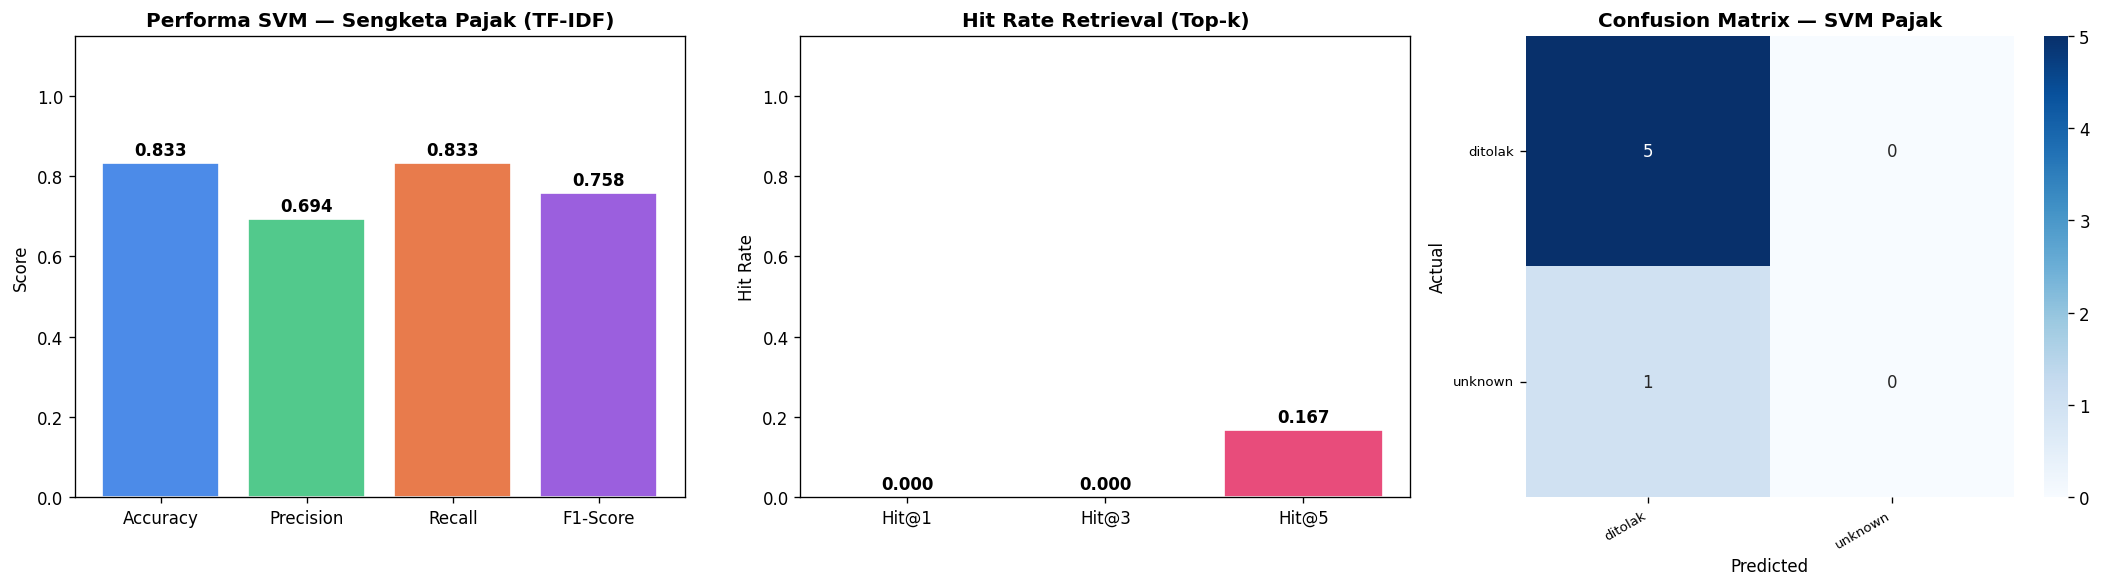

✅ Saved: data/eval/performance_chart.png


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Performa SVM ---
metrics_svm = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
ax1 = axes[0]
bars = ax1.bar(metrics_svm.keys(), metrics_svm.values(),
               color=['#4C8BE8','#52C98C','#E87B4C','#9B5FDE'], edgecolor='white')
ax1.set_title('Performa SVM — Sengketa Pajak (TF-IDF)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score')
for bar, val in zip(bars, metrics_svm.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# --- Plot 2: Hit Rate ---
ax2 = axes[1]
bars2 = ax2.bar([f'Hit@{r["k"]}' for r in results_retrieval],
                [r['hit_rate'] for r in results_retrieval],
                color=['#E8D44C','#4CC4E8','#E84C7B'], edgecolor='white')
ax2.set_title('Hit Rate Retrieval (Top-k)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('Hit Rate')
for bar, r in zip(bars2, results_retrieval):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{r['hit_rate']:.3f}", ha='center', fontsize=10, fontweight='bold')

# --- Plot 3: Confusion Matrix ---
ax3 = axes[2]
cm = confusion_matrix(y_test_eval, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax3.set_title('Confusion Matrix — SVM Pajak', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
plt.setp(ax3.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.setp(ax3.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(EVAL_DIR / 'performance_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: data/eval/performance_chart.png')

### 5.5 Analisis Kegagalan (Error Analysis)

In [51]:
df_pred = pd.read_csv(RESULTS_DIR / 'predictions.csv')
df_errors = df_pred[
    (df_pred['ground_truth_label'] != 'unknown') &
    (df_pred['predicted_label'] != 'unknown') &
    (df_pred['ground_truth_label'] != df_pred['predicted_label'])
]

print(f'Kasus gagal diprediksi: {len(df_errors)} dari {len(df_pred)}')

if not df_errors.empty:
    display(df_errors[['query_id','ground_truth_label','predicted_label','top_5_case_ids']])

print("""
Analisis Penyebab Kegagalan:
1. Tumpang tindih terminologi pajak antar kelas (misal PPh Badan dan PPh Orang Pribadi sama-sama menyebut penghasilan)
2. Distribusi kelas tidak seimbang (sengketa bea masuk lebih sedikit dibanding PPh)
3. Query terlalu pendek → vektor TF-IDF kurang representatif konteks sengketa

Rekomendasi Perbaikan:
- Tambah volume data (>50 dokumen) terutama kelas sengketa PBB dan bea masuk
- Tuning hyperparameter SVM (C, kernel='rbf')
- Coba IndoBERT embedding untuk representasi semantik hukum pajak yang lebih kaya
- Gunakan SMOTE untuk oversampling kelas minoritas
""")

Kasus gagal diprediksi: 0 dari 6

Analisis Penyebab Kegagalan:
1. Tumpang tindih terminologi pajak antar kelas (misal PPh Badan dan PPh Orang Pribadi sama-sama menyebut penghasilan)
2. Distribusi kelas tidak seimbang (sengketa bea masuk lebih sedikit dibanding PPh)
3. Query terlalu pendek → vektor TF-IDF kurang representatif konteks sengketa

Rekomendasi Perbaikan:
- Tambah volume data (>50 dokumen) terutama kelas sengketa PBB dan bea masuk
- Tuning hyperparameter SVM (C, kernel='rbf')
- Coba IndoBERT embedding untuk representasi semantik hukum pajak yang lebih kaya
- Gunakan SMOTE untuk oversampling kelas minoritas



### 5.6 Simpan Metrics ke CSV

In [52]:
df_retrieval_metrics = pd.DataFrame([
    {'model': 'TF-IDF + SVM', 'k': r['k'],  'metric': 'Hit Rate',  'value': r['hit_rate']}
    for r in results_retrieval
] + [
    {'model': 'TF-IDF + SVM', 'k': '-', 'metric': 'Accuracy',  'value': acc},
    {'model': 'TF-IDF + SVM', 'k': '-', 'metric': 'Precision', 'value': prec},
    {'model': 'TF-IDF + SVM', 'k': '-', 'metric': 'Recall',    'value': rec},
    {'model': 'TF-IDF + SVM', 'k': '-', 'metric': 'F1-Score',  'value': f1},
])
df_retrieval_metrics.to_csv(EVAL_DIR / 'retrieval_metrics.csv', index=False)

df_prediction_metrics = pd.DataFrame([{
    'accuracy': pred_acc, 'precision': pred_prec,
    'recall': pred_rec,   'f1': pred_f1
}])
df_prediction_metrics.to_csv(EVAL_DIR / 'prediction_metrics.csv', index=False)

print('✅ Saved: data/eval/retrieval_metrics.csv')
print('✅ Saved: data/eval/prediction_metrics.csv')
display(df_retrieval_metrics)


✅ Saved: data/eval/retrieval_metrics.csv
✅ Saved: data/eval/prediction_metrics.csv


,model,k,metric,value
0,TF-IDF + SVM,1,Hit Rate,0.000000
1,TF-IDF + SVM,3,Hit Rate,0.000000
2,TF-IDF + SVM,5,Hit Rate,0.166667
3,TF-IDF + SVM,-,Accuracy,0.833333
4,TF-IDF + SVM,-,Precision,0.694444
5,TF-IDF + SVM,-,Recall,0.833333
6,TF-IDF + SVM,-,F1-Score,0.757576
